In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

**Out-of-bag evaluation leverages unsampled instances in bootstrap aggregates to estimate ensemble performance without cross-validation, providing an efficient proxy for generalisation error by averaging OOB scores across base models.**



## Introduction to Out-of-Bag Evaluation
In bagging ensembles, bootstrap sampling with replacement ensures diversity among base models, but it also leaves a subset of training instances unsampled for each model. These **out-of-bag** (OOB) instances serve as a natural validation set, enabling performance estimation during training. OOB evaluation approximates the model's generalisation to unseen data, akin to cross-validation, but without additional computational overhead or data splitting.

This technique is particularly valuable for high-variance models like decision trees, where it quantifies ensemble robustness. By aggregating OOB predictions, it offers an unbiased metric, facilitating hyperparameter tuning and early stopping without a separate validation set.


### Theoretical Foundations
Bootstrap sampling from a dataset of size $N$ produces samples where each instance has probability $(1 - 1/N)^N \approx e^{-1} \approx 0.368$ of being excluded, yielding approximately 37% OOB instances per base model. Conversely, 63% are sampled on average, often with duplicates.

For an ensemble of $B$ base models $\hat{f}_b(\mathbf{x})$, each trained on bootstrap $\mathcal{D}_b$, the OOB prediction for instance $i$ averages outputs from models where $i$ is OOB:
$$
\hat{f}_{\text{OOB}}(\mathbf{x}_i) = \frac{1}{|B_i|} \sum_{b \in B_i} \hat{f}_b(\mathbf{x}_i),
$$
where $B_i$ is the set of models excluding $i$ from $\mathcal{D}_b$, and $|B_i| \approx 0.37B$.

The OOB error computes as the average loss over all instances using their OOB predictions. For classification (accuracy or error rate):
$$
\text{OOB error} = 1 - \frac{1}{N} \sum_{i=1}^N \mathbb{I}(y_i = \hat{f}_{\text{OOB}}(\mathbf{x}_i)).
$$
For regression (MSE):
$$
\text{OOB MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{f}_{\text{OOB}}(\mathbf{x}_i))^2.
$$

OOB approximates $K$-fold CV error as $B \to \infty$, converging to leave-one-out CV under bootstrap asymptotics. It underestimates variance slightly but correlates strongly with test error, enabling efficient validation.

### OOB Evaluation Process
During training, each base model evaluates on its OOB instances, yielding individual OOB scores $OOB_b$. The ensemble OOB score averages these:
$$
\text{OOB score} = \frac{1}{B} \sum_{b=1}^B OOB_b.
$$
This process integrates seamlessly into bagging, as OOB instances mimic held-out data.

OOB's efficiency stems from reusing training computations—no extra fits required. It suits large datasets where CV is costly, though for small $N$, OOB may overestimate error due to fewer OOB per instance.

To visualise:

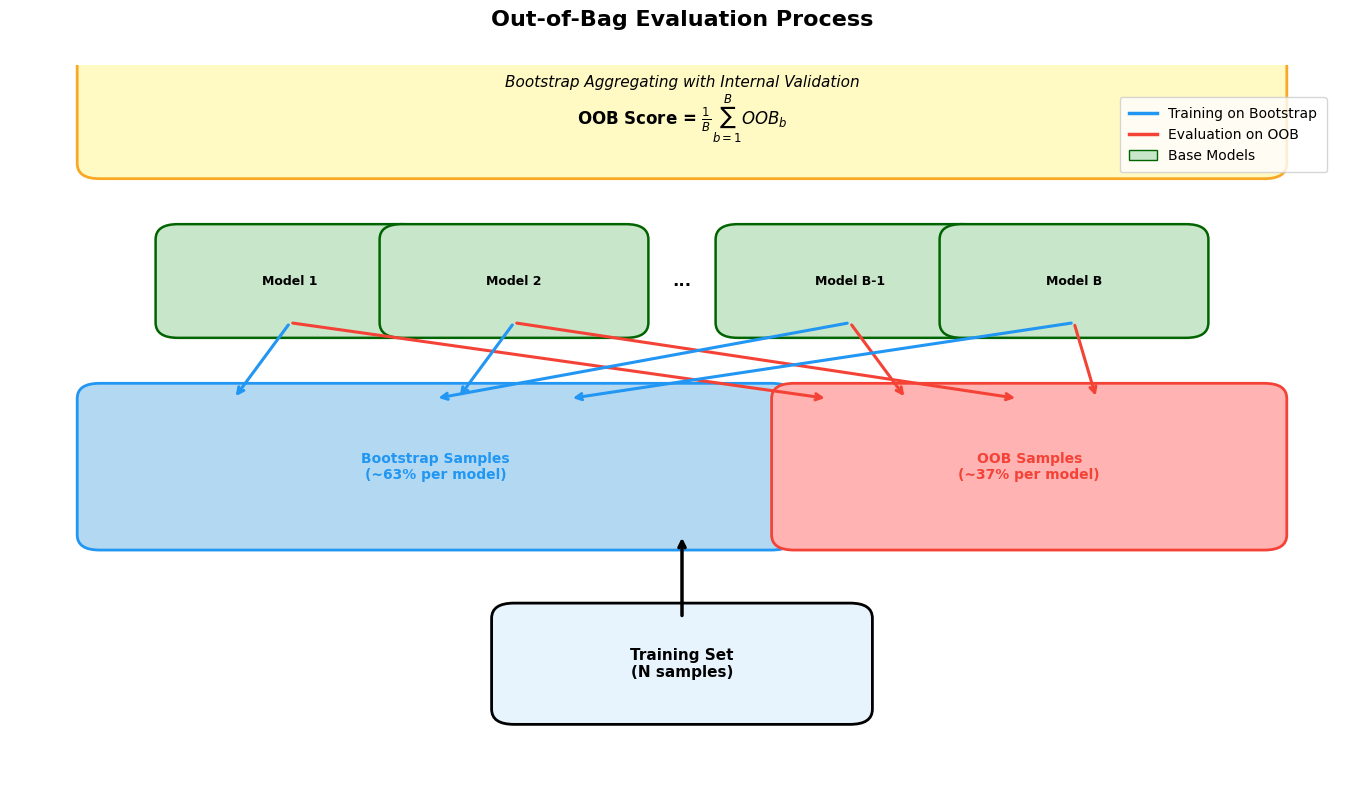

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
from matplotlib.lines import Line2D

# ----------------- FIGURE SETUP -----------------
fig, ax = plt.subplots(figsize=(14, 8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 9.5)
ax.axis("off")

colors = {
	"training": "#E8F4FD",
	"bootstrap": "#B3D9F2",
	"oob": "#FFB3B3",
	"model": "#C8E6C9",
	"arrow_blue": "#2196F3",
	"arrow_red": "#F44336",
}

# ----------------- VERTICAL LAYOUT -----------------
y_train = 1.0
h_train = 1.2

gap1 = 1.1
y_sample = y_train + h_train + gap1
h_sample = 1.8

gap2 = 1.0
y_model = y_sample + h_sample + gap2
h_model = 1.1

gap3 = 1.0
y_score = y_model + h_model + gap3
h_score = 1.5

title_y = y_score + h_score + 0.4

# ----------------- TITLE & SCORE BOX -----------------
ax.text(
	6,
	title_y,
	"Out-of-Bag Evaluation Process",
	ha="center",
	va="center",
	fontsize=16,
	fontweight="bold",
)

score_box = FancyBboxPatch(
	(0.8, y_score),
	10.4,
	h_score,
	boxstyle="round,pad=0.2",
	facecolor="#FFF9C4",
	edgecolor="#F9A825",
	linewidth=2,
	zorder=1,
)
ax.add_patch(score_box)

ax.text(
	6,
	y_score + h_score * 0.72,
	"Bootstrap Aggregating with Internal Validation",
	ha="center",
	va="center",
	fontsize=11,
	style="italic",
)

ax.text(
	6,
	y_score + h_score * 0.40,
	r"OOB Score = $\frac{1}{B}\sum_{b=1}^{B} OOB_b$",
	ha="center",
	va="center",
	fontsize=12,
	fontweight="bold",
)

# ----------------- TRAINING SET -----------------
train_box = FancyBboxPatch(
	(4.5, y_train),
	3.0,
	h_train,
	boxstyle="round,pad=0.2",
	facecolor=colors["training"],
	edgecolor="black",
	linewidth=2,
	zorder=1,
)
ax.add_patch(train_box)

ax.text(
	6.0,
	y_train + h_train / 2,
	"Training Set\n(N samples)",
	ha="center",
	va="center",
	fontsize=11,
	fontweight="bold",
)

# ----------------- SAMPLE BOXES -----------------
# Bootstrap box on the left
bootstrap_xmin = 0.8
bootstrap_width = 6.0
bootstrap_xmax = bootstrap_xmin + bootstrap_width

bootstrap_box = FancyBboxPatch(
	(bootstrap_xmin, y_sample),
	bootstrap_width,
	h_sample,
	boxstyle="round,pad=0.2",
	facecolor=colors["bootstrap"],
	edgecolor=colors["arrow_blue"],
	linewidth=2,
	zorder=1,
)
ax.add_patch(bootstrap_box)

ax.text(
	bootstrap_xmin + bootstrap_width / 2,
	y_sample + h_sample / 2,
	"Bootstrap Samples\n(~63% per model)",
	ha="center",
	va="center",
	fontsize=10,
	color=colors["arrow_blue"],
	fontweight="bold",
)

# OOB box on the right
oob_xmin = 7.0
oob_width = 4.2
oob_xmax = oob_xmin + oob_width

oob_box = FancyBboxPatch(
	(oob_xmin, y_sample),
	oob_width,
	h_sample,
	boxstyle="round,pad=0.2",
	facecolor=colors["oob"],
	edgecolor=colors["arrow_red"],
	linewidth=2,
	zorder=1,
)
ax.add_patch(oob_box)

ax.text(
	oob_xmin + oob_width / 2,
	y_sample + h_sample / 2,
	"OOB Samples\n(~37% per model)",
	ha="center",
	va="center",
	fontsize=10,
	color=colors["arrow_red"],
	fontweight="bold",
)

# ----------------- MODELS -----------------
w_model = 2.0
model_centres = [2.5, 4.5, 7.5, 9.5]
model_labels = ["Model 1", "Model 2", "Model B-1", "Model B"]

# Left models
for x, label in zip(model_centres[:2], model_labels[:2]):
	box = FancyBboxPatch(
		(x - w_model / 2, y_model),
		w_model,
		h_model,
		boxstyle="round,pad=0.2",
		facecolor=colors["model"],
		edgecolor="darkgreen",
		linewidth=1.8,
		zorder=1,
	)
	ax.add_patch(box)
	ax.text(
		x,
		y_model + h_model / 2,
		label,
		ha="center",
		va="center",
		fontsize=9,
		fontweight="bold",
	)

# Ellipsis in the middle
ax.text(
	6.0,
	y_model + h_model / 2,
	"...",
	ha="center",
	va="center",
	fontsize=12,
	fontweight="bold",
)

# Right models
for x, label in zip(model_centres[2:], model_labels[2:]):
	box = FancyBboxPatch(
		(x - w_model / 2, y_model),
		w_model,
		h_model,
		boxstyle="round,pad=0.2",
		facecolor=colors["model"],
		edgecolor="darkgreen",
		linewidth=1.8,
		zorder=1,
	)
	ax.add_patch(box)
	ax.text(
		x,
		y_model + h_model / 2,
		label,
		ha="center",
		va="center",
		fontsize=9,
		fontweight="bold",
	)

# ----------------- ARROWS -----------------
y_model_bottom = y_model
y_sample_top = y_sample + h_sample

arrow_blue = dict(
	arrowstyle="->",
	lw=2.2,
	color=colors["arrow_blue"],
	mutation_scale=11,
	joinstyle="round",
	capstyle="round",
)
arrow_red = dict(
	arrowstyle="->",
	lw=2.2,
	color=colors["arrow_red"],
	mutation_scale=11,
	joinstyle="round",
	capstyle="round",
)

# Manually chosen, symmetric targets so arrows are neat and in the correct box
left_models = model_centres[:2]
right_models = model_centres[2:]

# heads for bootstrap (blue) and OOB (red)
blue_left_targets = [2.0, 4.0]  # inside bootstrap box
red_left_targets = [7.3, 9.0]  # inside OOB box

blue_right_targets = [3.8, 5.0]  # inside bootstrap box
red_right_targets = [8.0, 9.7]  # inside OOB box

# left models: blue to bootstrap, red to OOB
for x_m, x_b, x_r in zip(left_models, blue_left_targets, red_left_targets):
	ax.annotate(
		"",
		xy=(x_b, y_sample_top),
		xytext=(x_m, y_model_bottom),
		arrowprops=arrow_blue,
		zorder=2,
	)
	ax.annotate(
		"",
		xy=(x_r, y_sample_top),
		xytext=(x_m, y_model_bottom),
		arrowprops=arrow_red,
		zorder=2,
	)

# right models: blue to bootstrap, red to OOB
for x_m, x_b, x_r in zip(right_models, blue_right_targets, red_right_targets):
	ax.annotate(
		"",
		xy=(x_b, y_sample_top),
		xytext=(x_m, y_model_bottom),
		arrowprops=arrow_blue,
		zorder=2,
	)
	ax.annotate(
		"",
		xy=(x_r, y_sample_top),
		xytext=(x_m, y_model_bottom),
		arrowprops=arrow_red,
		zorder=2,
	)

# training set → samples (vertical)
ax.annotate(
	"",
	xy=(6.0, y_sample),
	xytext=(6.0, y_train + h_train),
	arrowprops=dict(
		arrowstyle="->",
		lw=2.5,
		color="black",
		mutation_scale=11,
	),
	zorder=2,
)

# ----------------- LEGEND -----------------
legend_elements = [
	Line2D([0], [0], color=colors["arrow_blue"], lw=2.5, label="Training on Bootstrap"),
	Line2D([0], [0], color=colors["arrow_red"], lw=2.5, label="Evaluation on OOB"),
	mpatches.Patch(
		facecolor=colors["model"],
		edgecolor="darkgreen",
		label="Base Models",
	),
]

ax.legend(
	handles=legend_elements,
	loc="upper right",
	bbox_to_anchor=(0.985, 0.965),
	fontsize=10,
	frameon=True,
	fancybox=True,
	borderpad=0.7,
)

plt.subplots_adjust(left=0.02, right=0.98, top=0.95, bottom=0.05)
plt.show()


This schematic depicts training on bootstraps and evaluation on OOB, culminating in averaged scores.


### Implementation in Scikit-Learn
Scikit-learn's `BaggingClassifier` and `BaggingRegressor` support OOB via `oob_score=True`, computing accuracy (classification) or R² (regression) automatically.

Using Breast Cancer dataset:

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Seed
SEED = 1

# Split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.3, stratify=y, random_state=SEED
)

# Base classifier
base_clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=0.16, random_state=SEED)

# Bagging with OOB
bagging_clf = BaggingClassifier(
	estimator=base_clf, n_estimators=300, oob_score=True, random_state=SEED, n_jobs=-1
)

# Fit and predict
bagging_clf.fit(X_train, y_train)
y_pred = bagging_clf.predict(X_test)

# Metrics
test_acc = accuracy_score(y_test, y_pred)
oob_acc = bagging_clf.oob_score_

print(f"Test Accuracy: {test_acc:.3f}")
print(f"OOB Accuracy: {oob_acc:.3f}")

OOB accuracy approximates test accuracy, validating the ensemble without CV.


### Comparison with Cross-Validation
OOB correlates with $K$-fold CV but computes faster, using ~37% of data per model versus $1/K$. For small $N$, OOB variance may exceed CV's; hybrid approaches combine both.

Empirically, OOB underestimates performance slightly but suffices for tuning. In imbalanced classes, stratified bootstrapping preserves distributions.


### Practical Considerations and Extensions
OOB enables feature importance via permutation on OOB instances, extending to random forests. Limitations: unavailable without bootstrapping; for small $B$, unreliable.

Theoretically, OOB converges to true error under ergodicity, justifying its use in large ensembles. In practice, set $B \geq 100$ for stability, monitoring OOB for convergence.